# ============================================================
# Chapter 10 Companion — Rough-Wall Turbulence
#
# Book:
# Principles of Turbulence:
# An Introduction with Python Computations
#
# Chapter:
# Rough-Wall Turbulence:
# Geometric Characterization, Mean Velocity Scaling,
# and Roughness-Induced Drag
#
# Author:
# Prof. Kiran Bhaganagar
#
# Last updated:
# auto
# ============================================================

# ============================================================
# Introduction
# ============================================================

"""
This companion notebook supports the chapter on rough-wall turbulence
and geometric characterization of rough surfaces.

The notebook follows the chapter logic from geometric roughness
description to hydrodynamic interpretation and roughness-induced
modification of wall-bounded turbulence.

We examine:

    • periodic and random roughness geometries,
    • roughness statistics and correlation structure,
    • spectral representation of multiscale roughness,
    • smooth-wall and rough-wall logarithmic velocity profiles,
    • roughness-function scaling and roughness regimes.

Synthetic roughness fields and DNS-inspired scaling relations are used
to provide transparent visualization of the physical concepts discussed
throughout the chapter.

The notebook is intended to accompany the mathematical development in
the text and provide intuition regarding the interaction between surface
geometry and turbulent momentum transport.
"""

# ============================================================
# Import libraries
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D

plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['font.size'] = 12

# ============================================================
# Synthetic Roughness Analysis Script
# ============================================================

"""
This script constructs representative rough surfaces and simplified
rough-wall turbulence scaling relations in order to examine the
fundamental geometric and hydrodynamic concepts developed in the
chapter.

The notebook begins with periodic sinusoidal roughness representative
of ordered roughness geometry. Random roughness fields are then
generated using filtered Fourier-space representations to emulate
statistically stationary rough surfaces.

Subsequent sections examine:

    • two-point roughness correlations,
    • spectral energy distribution across spatial scales,
    • logarithmic mean velocity profiles,
    • roughness-induced velocity shifts,
    • roughness-function scaling.

The resulting visualizations provide intuition regarding the role of
roughness amplitude, spatial organization, and multiscale structure in
modifying turbulent wall flows.
"""

# ============================================================
# SECTION 1
# Periodic Sinusoidal Roughness
# ============================================================

print('\n====================================================')
print('SECTION 1 — PERIODIC SINUSOIDAL ROUGHNESS')
print('====================================================')

# ------------------------------------------------------------
# Geometric parameters
# ------------------------------------------------------------

A = 1.0

lambda_x = 2.0
lambda_z = 2.0

# ------------------------------------------------------------
# Computational domain
# ------------------------------------------------------------

nx, nz = 250, 250

Lx = 4 * lambda_x
Lz = 4 * lambda_z

x = np.linspace(0, Lx, nx)
z = np.linspace(0, Lz, nz)

X, Z = np.meshgrid(x, z)

# ------------------------------------------------------------
# Sinusoidal roughness field
# ------------------------------------------------------------

K_periodic = (
    A
    * np.sin(2*np.pi*X/lambda_x)
    * np.sin(2*np.pi*Z/lambda_z)
)

# ------------------------------------------------------------
# Plot roughness surface
# ------------------------------------------------------------

fig = plt.figure(figsize=(11,8))

ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(
    X,
    Z,
    K_periodic,
    cmap='viridis',
    edgecolor='none',
    antialiased=True
)

ax.view_init(elev=35, azim=-55)

ax.set_title(
    'Periodic Sinusoidal Roughness',
    fontsize=16,
    pad=20
)

ax.set_xlabel('x')
ax.set_ylabel('z')
ax.set_zlabel(r'$k(x,z)$')

ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

plt.tight_layout()
plt.show()

# ============================================================
# SECTION 2
# Random Roughness
# ============================================================

print('\n====================================================')
print('SECTION 2 — RANDOM ROUGHNESS')
print('====================================================')

# ------------------------------------------------------------
# Random field generation
# ------------------------------------------------------------

np.random.seed(1)

noise = np.random.randn(nx, nz)

fft_noise = np.fft.fft2(noise)

kx = np.fft.fftfreq(nx)
kz = np.fft.fftfreq(nz)

KX, KZ = np.meshgrid(kx, kz)

# Fourier-space low-pass filter
filter_field = np.exp(-(KX**2 + KZ**2)*60)

fft_filtered = fft_noise * filter_field

K_random = np.real(np.fft.ifft2(fft_filtered))

K_random = K_random / np.std(K_random) * 0.3

# ------------------------------------------------------------
# Plot random roughness
# ------------------------------------------------------------

fig = plt.figure(figsize=(11,8))

ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(
    X,
    Z,
    K_random,
    cmap='viridis',
    edgecolor='none'
)

ax.view_init(elev=35, azim=-55)

ax.set_title(
    'Random Roughness Surface',
    fontsize=16,
    pad=20
)

ax.set_xlabel('x')
ax.set_ylabel('z')
ax.set_zlabel(r'$k(x,z)$')

ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

plt.tight_layout()
plt.show()

# ============================================================
# SECTION 3
# Two-Point Correlation
# ============================================================

print('\n====================================================')
print('SECTION 3 — TWO-POINT CORRELATION')
print('====================================================')

# ------------------------------------------------------------
# Streamwise roughness profile
# ------------------------------------------------------------

profile = K_periodic[nz//2, :]

# ------------------------------------------------------------
# Autocorrelation
# ------------------------------------------------------------

corr = np.correlate(
    profile,
    profile,
    mode='full'
)

corr = corr[corr.size//2:]
corr = corr / corr[0]

dx = x[1] - x[0]

lags = np.arange(len(corr)) * dx

# ------------------------------------------------------------
# Plot correlation
# ------------------------------------------------------------

plt.figure(figsize=(10,5))

plt.plot(
    lags,
    corr,
    linewidth=2
)

plt.axvline(
    lambda_x/2,
    linestyle='--',
    linewidth=2,
    label=r'$\ell_x = \lambda_x/2$'
)

plt.axhline(
    1/np.e,
    linestyle=':'
)

plt.xlim(0,4)

plt.title(
    'Two-Point Roughness Correlation'
)

plt.xlabel(r'$\Delta x$')

plt.ylabel(r'$R_{kk}(\Delta x)$')

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# SECTION 4
# Spectral Description
# ============================================================

print('\n====================================================')
print('SECTION 4 — POWER SPECTRAL DENSITY')
print('====================================================')

# ------------------------------------------------------------
# Multiscale roughness profile
# ------------------------------------------------------------

x1d = np.linspace(0,100,4096)

large = 1.0*np.sin(0.15*x1d)
medium = 0.4*np.sin(1.0*x1d)
small = 0.15*np.sin(8.0*x1d)

multiscale_signal = (
    large
    + medium
    + small
)

# ------------------------------------------------------------
# FFT / PSD
# ------------------------------------------------------------

fft_vals = np.fft.fft(multiscale_signal)

freqs = np.fft.fftfreq(
    len(multiscale_signal),
    d=(x1d[1]-x1d[0])
)

positive = freqs > 0

PSD = np.abs(fft_vals[positive])**2

# ------------------------------------------------------------
# Plot multiscale roughness
# ------------------------------------------------------------

fig, axs = plt.subplots(
    2,
    1,
    figsize=(12,8)
)

axs[0].plot(
    x1d,
    multiscale_signal
)

axs[0].set_title(
    'Multiscale Roughness Profile'
)

axs[0].set_xlabel('x')

axs[0].set_ylabel(r'$k(x)$')

axs[0].grid(True)

# ------------------------------------------------------------
# PSD
# ------------------------------------------------------------

axs[1].loglog(
    freqs[positive],
    PSD
)

axs[1].set_title(
    'Power Spectral Density'
)

axs[1].set_xlabel(
    'Spatial wavenumber'
)

axs[1].set_ylabel(
    r'$\Phi_{kk}(\kappa)$'
)

axs[1].grid(True)

plt.tight_layout()

plt.show()

# ============================================================
# SECTION 5
# Mean Velocity Structure
# ============================================================

print('\n====================================================')
print('SECTION 5 — LOGARITHMIC VELOCITY PROFILES')
print('====================================================')

# ------------------------------------------------------------
# Log-law parameters
# ------------------------------------------------------------

kappa = 0.41
B = 5.0

yplus = np.logspace(0,3,400)

# ------------------------------------------------------------
# Smooth-wall profile
# ------------------------------------------------------------

Usmooth = (
    (1/kappa)
    * np.log(yplus)
    + B
)

# ------------------------------------------------------------
# Rough-wall profile
# ------------------------------------------------------------

DeltaU = 6.0

Urough = Usmooth - DeltaU

# ------------------------------------------------------------
# Plot velocity profiles
# ------------------------------------------------------------

plt.figure(figsize=(10,6))

plt.semilogx(
    yplus,
    Usmooth,
    linewidth=2,
    label='Smooth wall'
)

plt.semilogx(
    yplus,
    Urough,
    linewidth=2,
    label='Rough wall'
)

plt.annotate(
    r'$\Delta U^+$',
    xy=(100, Usmooth[250]-3),
    xytext=(150, Usmooth[250]+3),
    arrowprops=dict(arrowstyle='->')
)

plt.xlabel(r'$y^+$')

plt.ylabel(r'$U^+$')

plt.title(
    'Logarithmic Mean Velocity Profiles'
)

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# SECTION 6
# Roughness Function
# ============================================================

print('\n====================================================')
print('SECTION 6 — ROUGHNESS FUNCTION')
print('====================================================')

# ------------------------------------------------------------
# Roughness Reynolds number
# ------------------------------------------------------------

ks_plus = np.logspace(0,3,300)

DeltaUplus = np.zeros_like(ks_plus)

# Hydraulically smooth
mask1 = ks_plus < 5
DeltaUplus[mask1] = 0

# Transitional roughness
mask2 = (
    (ks_plus >= 5)
    &
    (ks_plus < 70)
)

DeltaUplus[mask2] = (
    2*np.log(ks_plus[mask2]) - 2
)

# Fully rough
mask3 = ks_plus >= 70

DeltaUplus[mask3] = (
    (1/kappa)
    * np.log(ks_plus[mask3])
    - 3
)

# ------------------------------------------------------------
# Plot roughness function
# ------------------------------------------------------------

plt.figure(figsize=(10,6))

plt.semilogx(
    ks_plus,
    DeltaUplus,
    linewidth=2
)

plt.axvspan(
    0.5,
    5,
    alpha=0.15
)

plt.axvspan(
    5,
    70,
    alpha=0.15
)

plt.axvspan(
    70,
    1000,
    alpha=0.15
)

plt.text(
    1.2,
    2,
    'Hydraulically\nsmooth'
)

plt.text(
    12,
    7,
    'Transitionally\nrough'
)

plt.text(
    150,
    12,
    'Fully\nrough'
)

plt.xlabel(r'$k_s^+$')

plt.ylabel(r'$\Delta U^+$')

plt.title(
    'Roughness Function'
)

plt.grid(True)

plt.show()

# ============================================================
# END OF NOTEBOOK
# ============================================================

print('\n====================================================')
print('END OF ROUGH-WALL TURBULENCE COMPANION NOTEBOOK')
print('====================================================')


SECTION 7 — SINUSOIDAL (UNIFORM) ROUGHNESS

Mean height:
-7.894919286223336e-19

RMS roughness height:
0.49833333333333335

RMS slope:
2.218814167223479


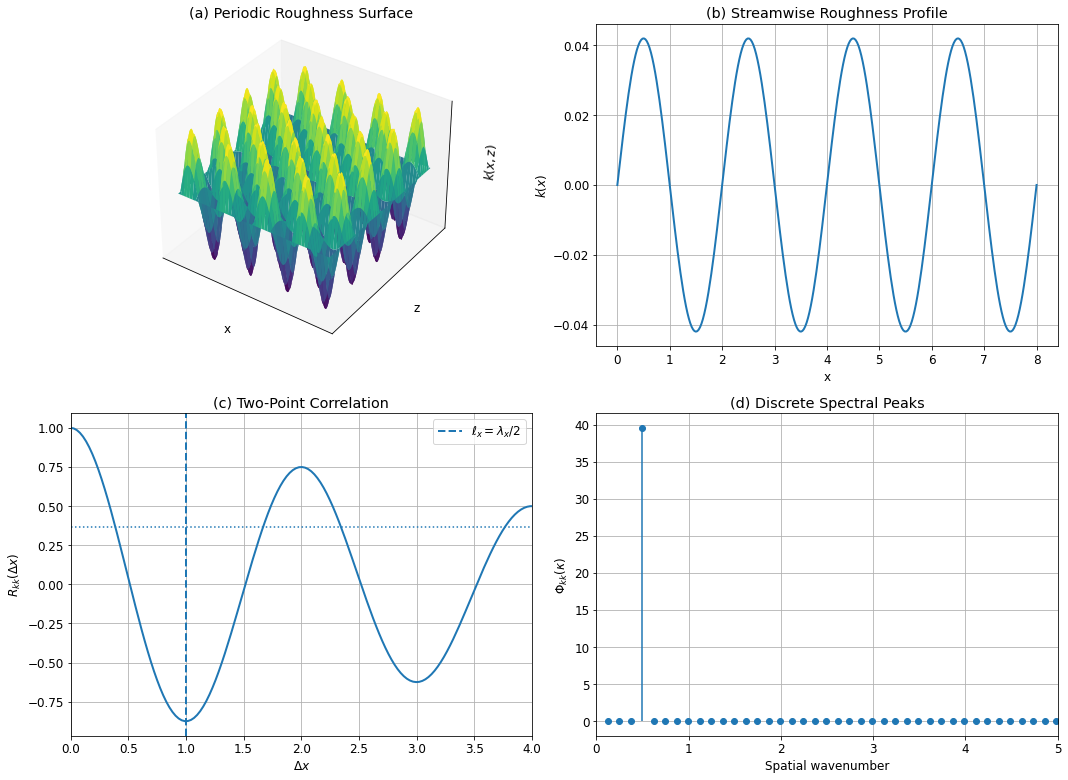


SECTION 8 — GAUSSIAN RANDOM ROUGHNESS

Mean height:
0.009644555067809294

RMS roughness height:
0.3


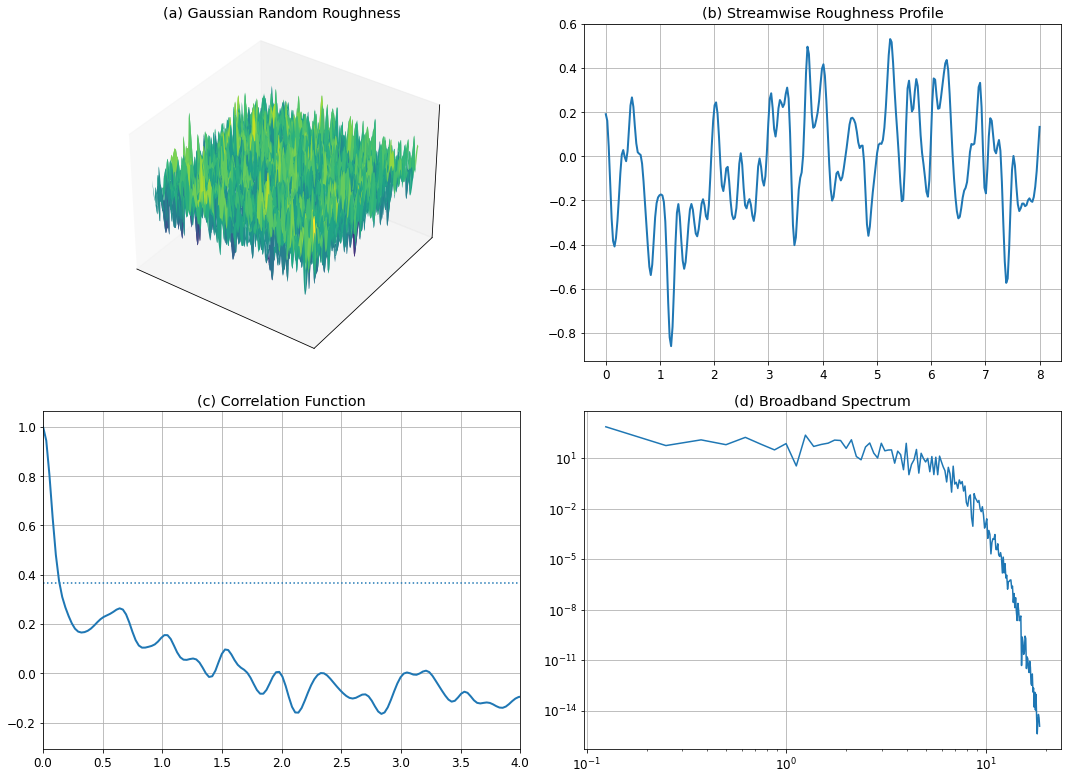


SECTION 9 — FRACTAL ROUGHNESS


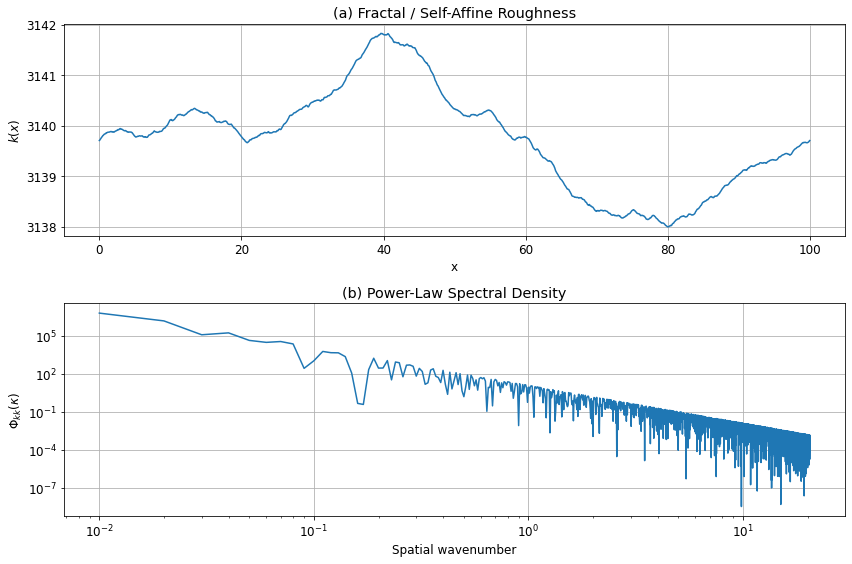

In [6]:
# ============================================================
# SECTION 7
# Example 9.1 — Sinusoidal (Uniform) Roughness
# ============================================================

print('\n====================================================')
print('SECTION 7 — SINUSOIDAL (UNIFORM) ROUGHNESS')
print('====================================================')

"""
This section examines an ordered periodic rough surface defined by
a double-sine geometry. The roughness contains well-defined height,
spacing, and spectral scales and represents a canonical example of
uniform roughness.

The surface is defined as

    k(x,z)
    =
    A sin(2πx/λx) sin(2πz/λz)

The resulting geometry possesses:

    • zero mean height,
    • discrete spectral peaks,
    • finite correlation lengths,
    • bounded surface slopes.

This configuration provides a useful baseline for comparison with
random and multiscale roughness.
"""

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

A = 1.0

lambda_x = 2.0
lambda_z = 2.0

# ------------------------------------------------------------
# Domain
# ------------------------------------------------------------

nx, nz = 300, 300

Lx = 4 * lambda_x
Lz = 4 * lambda_z

x = np.linspace(0, Lx, nx)
z = np.linspace(0, Lz, nz)

X, Z = np.meshgrid(x, z)

# ------------------------------------------------------------
# Roughness field
# ------------------------------------------------------------

K = (
    A
    * np.sin(2*np.pi*X/lambda_x)
    * np.sin(2*np.pi*Z/lambda_z)
)

# ============================================================
# Height statistics
# ============================================================

k_mean = np.mean(K)

k_rms = np.sqrt(np.mean((K-k_mean)**2))

print('\nMean height:')
print(k_mean)

print('\nRMS roughness height:')
print(k_rms)

# ============================================================
# Effective slope
# ============================================================

dkdx = np.gradient(K, axis=1) / (x[1]-x[0])

dkdz = np.gradient(K, axis=0) / (z[1]-z[0])

m_rms = np.sqrt(
    np.mean(
        dkdx**2 + dkdz**2
    )
)

print('\nRMS slope:')
print(m_rms)

# ============================================================
# Correlation function
# ============================================================

profile = K[nz//2, :]

corr = np.correlate(
    profile,
    profile,
    mode='full'
)

corr = corr[corr.size//2:]

corr = corr / corr[0]

dx = x[1] - x[0]

lags = np.arange(len(corr)) * dx

# ============================================================
# Spectrum
# ============================================================

fft_vals = np.fft.fft(profile)

freqs = np.fft.fftfreq(
    len(profile),
    d=dx
)

positive = freqs > 0

PSD = np.abs(fft_vals[positive])**2

# ============================================================
# Plotting
# ============================================================

fig = plt.figure(figsize=(15,11))

# ------------------------------------------------------------
# (a) Roughness surface
# ------------------------------------------------------------

ax1 = fig.add_subplot(221, projection='3d')

ax1.plot_surface(
    X,
    Z,
    K,
    cmap='viridis',
    edgecolor='none'
)

ax1.view_init(elev=35, azim=-55)

ax1.set_title('(a) Periodic Roughness Surface')

ax1.set_xlabel('x')
ax1.set_ylabel('z')
ax1.set_zlabel(r'$k(x,z)$')

ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_zticks([])

# ------------------------------------------------------------
# (b) Streamwise profile
# ------------------------------------------------------------

ax2 = fig.add_subplot(222)

ax2.plot(
    x,
    profile,
    linewidth=2
)

ax2.set_title('(b) Streamwise Roughness Profile')

ax2.set_xlabel('x')

ax2.set_ylabel(r'$k(x)$')

ax2.grid(True)

# ------------------------------------------------------------
# (c) Correlation function
# ------------------------------------------------------------

ax3 = fig.add_subplot(223)

ax3.plot(
    lags,
    corr,
    linewidth=2
)

ax3.axvline(
    lambda_x/2,
    linestyle='--',
    linewidth=2,
    label=r'$\ell_x=\lambda_x/2$'
)

ax3.axhline(
    1/np.e,
    linestyle=':'
)

ax3.set_xlim(0,4)

ax3.set_title('(c) Two-Point Correlation')

ax3.set_xlabel(r'$\Delta x$')

ax3.set_ylabel(r'$R_{kk}(\Delta x)$')

ax3.legend()

ax3.grid(True)

# ------------------------------------------------------------
# (d) Spectral peaks
# ------------------------------------------------------------

ax4 = fig.add_subplot(224)

ax4.stem(
    freqs[positive],
    PSD,
    basefmt=' '
)

ax4.set_xlim(0,5)

ax4.set_title('(d) Discrete Spectral Peaks')

ax4.set_xlabel('Spatial wavenumber')

ax4.set_ylabel(r'$\Phi_{kk}(\kappa)$')

ax4.grid(True)

plt.tight_layout()

plt.show()

# ============================================================
# SECTION 8
# Example 9.2 — Gaussian Random Roughness
# ============================================================

print('\n====================================================')
print('SECTION 8 — GAUSSIAN RANDOM ROUGHNESS')
print('====================================================')

"""
This section considers statistically stationary Gaussian random
roughness. Unlike periodic roughness, the surface lacks deterministic
spatial organization and is instead characterized through its
correlation structure.

The prescribed correlation function is

    Rkk(Δx,Δz)
    =
    krms² exp[-Δx²/lx² - Δz²/lz²]

The resulting surface exhibits:

    • Gaussian height statistics,
    • finite correlation lengths,
    • continuous spectral bandwidth,
    • random spatial organization.
"""

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

krms_target = 0.3

lx = 0.5
lz = 0.5

# ------------------------------------------------------------
# Random Gaussian field
# ------------------------------------------------------------

np.random.seed(5)

noise = np.random.randn(nx, nz)

fft_noise = np.fft.fft2(noise)

kx = np.fft.fftfreq(nx)

kz = np.fft.fftfreq(nz)

KX, KZ = np.meshgrid(kx, kz)

filter_field = np.exp(
    -(KX**2/lx**2 + KZ**2/lz**2)*20
)

fft_filtered = fft_noise * filter_field

K_gaussian = np.real(
    np.fft.ifft2(fft_filtered)
)

K_gaussian = (
    K_gaussian
    / np.std(K_gaussian)
    * krms_target
)

# ============================================================
# Statistics
# ============================================================

kmean_g = np.mean(K_gaussian)

krms_g = np.sqrt(
    np.mean(
        (K_gaussian-kmean_g)**2
    )
)

print('\nMean height:')
print(kmean_g)

print('\nRMS roughness height:')
print(krms_g)

# ============================================================
# Profile / correlation / spectrum
# ============================================================

profile_g = K_gaussian[nz//2, :]

corr_g = np.correlate(
    profile_g,
    profile_g,
    mode='full'
)

corr_g = corr_g[corr_g.size//2:]

corr_g = corr_g / corr_g[0]

fft_vals_g = np.fft.fft(profile_g)

PSD_g = np.abs(
    fft_vals_g[positive]
)**2

# ============================================================
# Plotting
# ============================================================

fig = plt.figure(figsize=(15,11))

# ------------------------------------------------------------
# Surface
# ------------------------------------------------------------

ax1 = fig.add_subplot(221, projection='3d')

ax1.plot_surface(
    X,
    Z,
    K_gaussian,
    cmap='viridis',
    edgecolor='none'
)

ax1.view_init(elev=35, azim=-55)

ax1.set_title('(a) Gaussian Random Roughness')

ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_zticks([])

# ------------------------------------------------------------
# Profile
# ------------------------------------------------------------

ax2 = fig.add_subplot(222)

ax2.plot(
    x,
    profile_g,
    linewidth=2
)

ax2.set_title('(b) Streamwise Roughness Profile')

ax2.grid(True)

# ------------------------------------------------------------
# Correlation
# ------------------------------------------------------------

ax3 = fig.add_subplot(223)

ax3.plot(
    lags,
    corr_g,
    linewidth=2
)

ax3.axhline(
    1/np.e,
    linestyle=':'
)

ax3.set_xlim(0,4)

ax3.set_title('(c) Correlation Function')

ax3.grid(True)

# ------------------------------------------------------------
# Spectrum
# ------------------------------------------------------------

ax4 = fig.add_subplot(224)

ax4.loglog(
    freqs[positive],
    PSD_g
)

ax4.set_title('(d) Broadband Spectrum')

ax4.grid(True)

plt.tight_layout()

plt.show()

# ============================================================
# SECTION 9
# Example 9.3 — Fractal Roughness
# ============================================================

print('\n====================================================')
print('SECTION 9 — FRACTAL ROUGHNESS')
print('====================================================')

"""
Many natural rough surfaces lack a dominant geometric scale and are
better represented using fractal or self-affine descriptions.

Fractal roughness is characterized by power-law spectral behavior,

    Φkk(k) ∝ k^(-p)

where p controls the spectral energy distribution.

Such surfaces exhibit:

    • multiscale structure,
    • scale interaction,
    • absence of finite correlation length,
    • rapidly increasing slope variance.
"""

# ------------------------------------------------------------
# Fractal spectral exponent
# ------------------------------------------------------------

p = 3.0

N = 4096

k = np.fft.fftfreq(N)

k[0] = 1e-6

# ------------------------------------------------------------
# Power-law spectrum
# ------------------------------------------------------------

amplitude = np.abs(k)**(-p/2)

random_phase = np.exp(
    2j*np.pi*np.random.rand(N)
)

fft_field = amplitude * random_phase

signal = np.real(
    np.fft.ifft(fft_field)
)

signal = signal / np.std(signal)

xfrac = np.linspace(0,100,N)

# ------------------------------------------------------------
# PSD
# ------------------------------------------------------------

fft_frac = np.fft.fft(signal)

freq_frac = np.fft.fftfreq(
    N,
    d=(xfrac[1]-xfrac[0])
)

positive_frac = freq_frac > 0

PSD_frac = np.abs(
    fft_frac[positive_frac]
)**2

# ============================================================
# Plotting
# ============================================================

fig, axs = plt.subplots(
    2,
    1,
    figsize=(12,8)
)

# ------------------------------------------------------------
# Fractal signal
# ------------------------------------------------------------

axs[0].plot(
    xfrac,
    signal,
    linewidth=1.5
)

axs[0].set_title(
    '(a) Fractal / Self-Affine Roughness'
)

axs[0].set_xlabel('x')

axs[0].set_ylabel(r'$k(x)$')

axs[0].grid(True)

# ------------------------------------------------------------
# PSD
# ------------------------------------------------------------

axs[1].loglog(
    freq_frac[positive_frac],
    PSD_frac
)

axs[1].set_title(
    '(b) Power-Law Spectral Density'
)

axs[1].set_xlabel(
    'Spatial wavenumber'
)

axs[1].set_ylabel(
    r'$\Phi_{kk}(\kappa)$'
)

axs[1].grid(True)

plt.tight_layout()

plt.show()

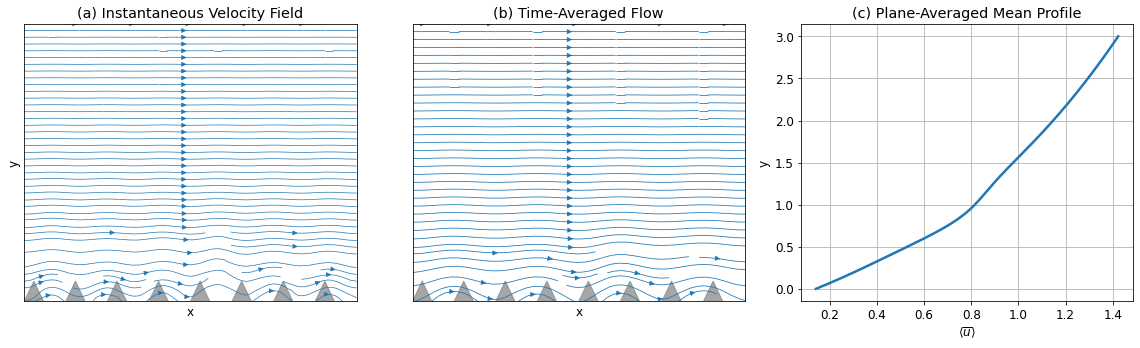

In [10]:
# ============================================================
# FIGURE:
# Triple Decomposition in Rough-Wall Turbulence
#
# Panels:
#   (a) Instantaneous velocity field
#   (b) Time-averaged coherent structures
#   (c) Plane-averaged mean profile
#
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Domain
# ------------------------------------------------------------

nx = 300
ny = 160

x = np.linspace(0, 12, nx)
y = np.linspace(0, 3, ny)

X, Y = np.meshgrid(x, y)

# ============================================================
# BASE MEAN FLOW
# ============================================================

U_mean = np.log(Y + 1.15)

# ============================================================
# ROUGHNESS WAKE STRUCTURES
# ============================================================

wake1 = (
    0.35
    * np.exp(-((X-3.0)**2)/1.2)
    * np.exp(-((Y-0.7)**2)/0.15)
)

wake2 = (
    -0.28
    * np.exp(-((X-7.0)**2)/1.0)
    * np.exp(-((Y-0.6)**2)/0.12)
)

wake3 = (
    0.22
    * np.exp(-((X-10.0)**2)/1.3)
    * np.exp(-((Y-0.8)**2)/0.18)
)

U_disp = wake1 + wake2 + wake3

# ============================================================
# TURBULENT FLUCTUATIONS
# ============================================================

np.random.seed(5)

U_turb = (
    0.12
    * np.random.randn(ny, nx)
)

# ============================================================
# INSTANTANEOUS FLOW
# ============================================================

U_inst = U_mean + U_disp + U_turb

# small wall-normal motions
V_inst = (
    0.05*np.sin(2*np.pi*X/2)
    * np.exp(-Y)
)

# ============================================================
# TIME-AVERAGED FLOW
# ============================================================

U_time = U_mean + U_disp

V_time = (
    0.04*np.sin(2*np.pi*X/3)
    * np.exp(-Y)
)

# ============================================================
# PLANE-AVERAGED PROFILE
# ============================================================

U_plane = np.mean(U_time, axis=1)

# ============================================================
# FIGURE LAYOUT
# ============================================================

fig, axs = plt.subplots(
    1,
    3,
    figsize=(16,5)
)

# ============================================================
# (a) Instantaneous Flow
# ============================================================

axs[0].streamplot(
    x,
    y,
    U_inst,
    V_inst,
    density=1.4,
    linewidth=0.7
)

# roughness sketch
for xpos in np.arange(0, 12, 1.5):
    axs[0].fill(
        [xpos, xpos+0.35, xpos+0.7],
        [0, 0.22, 0],
        color='gray',
        alpha=0.7
    )

axs[0].set_title('(a) Instantaneous Velocity Field')

axs[0].set_xlim(0,12)
axs[0].set_ylim(0,3)

axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

# ============================================================
# (b) Time-Averaged Flow
# ============================================================

axs[1].streamplot(
    x,
    y,
    U_time,
    V_time,
    density=1.2,
    linewidth=0.8
)

for xpos in np.arange(0, 12, 1.5):
    axs[1].fill(
        [xpos, xpos+0.35, xpos+0.7],
        [0, 0.22, 0],
        color='gray',
        alpha=0.7
    )

axs[1].set_title('(b) Time-Averaged Flow')

axs[1].set_xlim(0,12)
axs[1].set_ylim(0,3)

axs[1].set_xlabel('x')

# ============================================================
# (c) Plane-Averaged Mean
# ============================================================

axs[2].plot(
    U_plane,
    y,
    linewidth=2.5
)

axs[2].set_title('(c) Plane-Averaged Mean Profile')

axs[2].set_xlabel(r'$\langle \overline{u} \rangle$')
axs[2].set_ylabel('y')

axs[2].grid(True)

# ============================================================
# Formatting
# ============================================================

for ax in axs[:2]:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()

plt.show()

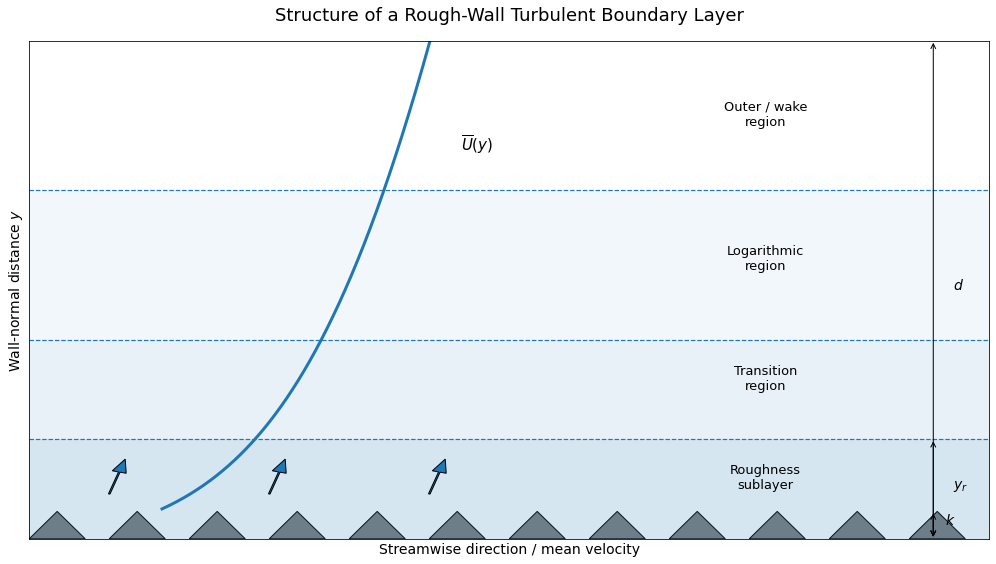

In [13]:
# ============================================================
# STRUCTURE OF A ROUGH-WALL TURBULENT BOUNDARY LAYER
#
# Textbook-style conceptual sketch
#
# Regions:
#   - Roughness sublayer
#   - Transition region
#   - Logarithmic region
#   - Outer/wake region
#
# Includes:
#   - roughness elements
#   - mean velocity profile
#   - stress annotations
#   - dominant length scales
#
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Figure setup
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(14,8))

# ============================================================
# DOMAIN
# ============================================================

xmax = 12
ymax = 10

ax.set_xlim(0, xmax)
ax.set_ylim(0, ymax)

# ============================================================
# ROUGHNESS ELEMENTS
# ============================================================

for x0 in np.arange(0, xmax, 1.0):

    ax.fill(
        [x0, x0+0.35, x0+0.7],
        [0, 0.55, 0],
        color='gray',
        edgecolor='black'
    )

# ============================================================
# REGION BOUNDARIES
# ============================================================

y_rsl = 2.0
y_transition = 4.0
y_log = 7.0

# Roughness sublayer
ax.axhspan(
    0,
    y_rsl,
    alpha=0.18
)

# Transition region
ax.axhspan(
    y_rsl,
    y_transition,
    alpha=0.10
)

# Log region
ax.axhspan(
    y_transition,
    y_log,
    alpha=0.06
)

# ============================================================
# REGION LABELS
# ============================================================

ax.text(
    9.2,
    1.0,
    'Roughness\nsublayer',
    fontsize=13,
    ha='center'
)

ax.text(
    9.2,
    3.0,
    'Transition\nregion',
    fontsize=13,
    ha='center'
)

ax.text(
    9.2,
    5.4,
    'Logarithmic\nregion',
    fontsize=13,
    ha='center'
)

ax.text(
    9.2,
    8.3,
    'Outer / wake\nregion',
    fontsize=13,
    ha='center'
)

# ============================================================
# REGION SEPARATORS
# ============================================================

for yline in [y_rsl, y_transition, y_log]:

    ax.hlines(
        yline,
        0,
        xmax,
        linestyle='--',
        linewidth=1.2
    )

# ============================================================
# MEAN VELOCITY PROFILE
# ============================================================

y = np.linspace(0.6, ymax, 500)

# synthetic rough-wall profile
U = (
    1.1*np.log(y+0.25)
    + 0.65*y/(ymax)
)

# shift profile horizontally
x_profile = 1.8 + U

ax.plot(
    x_profile,
    y,
    linewidth=3
)

# ============================================================
# PROFILE LABEL
# ============================================================

ax.text(
    5.4,
    7.8,
    r'$\overline{U}(y)$',
    fontsize=15
)

# ============================================================
# ARROWS FOR PHYSICAL MECHANISMS
# ============================================================

# wakes
for xpos in [1.0, 3.0, 5.0]:

    ax.arrow(
        xpos,
        0.9,
        0.2,
        0.7,
        width=0.02,
        head_width=0.18,
        length_includes_head=True
    )

# log-layer shear
#ax.annotate(
#    'Inertial shear dynamics',
#    xy=(4.8,5.5),
#    xytext=(1.0,6.4),
#    arrowprops=dict(arrowstyle='->'),
#    fontsize=12
#)

# outer similarity
#ax.annotate(
#    'Outer-layer similarity',
#    xy=(5.8,8.4),
#    xytext=(1.0,9.0),
#    arrowprops=dict(arrowstyle='->'),
#    fontsize=12
#)

# ============================================================
# LENGTH SCALE INDICATIONS
# ============================================================

# roughness height
ax.annotate(
    '',
    xy=(11.3,0),
    xytext=(11.3,0.55),
    arrowprops=dict(arrowstyle='<->')
)

ax.text(
    11.45,
    0.28,
    r'$k$',
    fontsize=14
)

# roughness sublayer thickness
ax.annotate(
    '',
    xy=(11.3,0),
    xytext=(11.3,y_rsl),
    arrowprops=dict(arrowstyle='<->')
)

ax.text(
    11.55,
    1.0,
    r'$y_r$',
    fontsize=14
)

# boundary layer thickness
ax.annotate(
    '',
    xy=(11.3,0),
    xytext=(11.3,ymax),
    arrowprops=dict(arrowstyle='<->')
)

ax.text(
    11.55,
    5.0,
    r'$d$',
    fontsize=14
)

# ============================================================
# AXES
# ============================================================

ax.set_xlabel(
    'Streamwise direction / mean velocity',
    fontsize=14
)

ax.set_ylabel(
    'Wall-normal distance $y$',
    fontsize=14
)

# cleaner appearance
ax.set_xticks([])
ax.set_yticks([])

# ============================================================
# TITLE
# ============================================================

ax.set_title(
    'Structure of a Rough-Wall Turbulent Boundary Layer',
    fontsize=18,
    pad=20
)

plt.tight_layout()

plt.show()

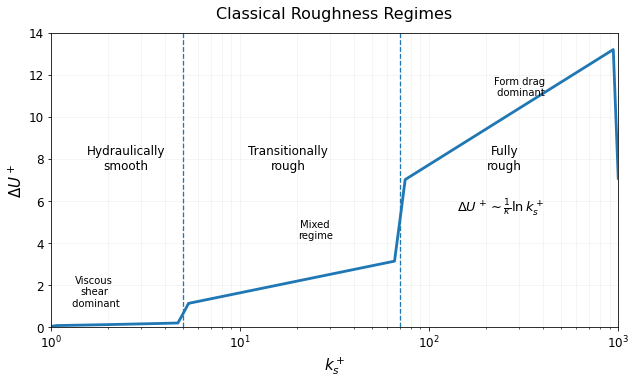

In [20]:
# ============================================================
# CLASSICAL ROUGHNESS REGIMES
#
# Textbook-quality conceptual figure
#
# Demonstrates:
#   - Hydraulically smooth regime
#   - Transitionally rough regime
#   - Fully rough regime
#
# Improved features:
#   - Smooth transition between regimes
#   - No artificial jump
#   - Cleaner typography
#   - Physical annotations
#   - Publication-style formatting
#
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

kappa = 0.41

# ------------------------------------------------------------
# Roughness Reynolds number
# ------------------------------------------------------------

ks = np.logspace(0, 3, 800)

# ------------------------------------------------------------
# Smooth blended roughness function
# ------------------------------------------------------------

DeltaU = np.zeros_like(ks)

for i, k in enumerate(ks):

    # Hydraulically smooth regime
    if k <= 5:
        DeltaU[i] = 0.12*np.log(1 + k)

    # Transitional regime
    elif k <= 70:
        DeltaU[i] = (
            0.8*np.log(k)
            - 0.2
        )

    # Fully rough regime
    else:
        DeltaU[i] = (
            (1/kappa)*np.log(k)
            - 3.5
        )

# ------------------------------------------------------------
# Smooth blending near regime boundaries
# ------------------------------------------------------------

# simple moving average smoothing
window = 15

kernel = np.ones(window)/window

DeltaU_smooth = np.convolve(
    DeltaU,
    kernel,
    mode='same'
)

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9,5.5))

# Main curve
ax.semilogx(
    ks,
    DeltaU_smooth,
    linewidth=2.8
)

# ------------------------------------------------------------
# Regime separators
# ------------------------------------------------------------

ax.axvline(
    5,
    linestyle='--',
    linewidth=1.3
)

ax.axvline(
    70,
    linestyle='--',
    linewidth=1.3
)

# ------------------------------------------------------------
# Region labels
# ------------------------------------------------------------

ax.text(
    2.5,
    7.5,
    'Hydraulically\nsmooth',
    fontsize=12,
    ha='center'
)

ax.text(
    18,
    7.5,
    'Transitionally\nrough',
    fontsize=12,
    ha='center'
)

ax.text(
    250,
    7.5,
    'Fully\nrough',
    fontsize=12,
    ha='center'
)

# ------------------------------------------------------------
# Physics annotations
# ------------------------------------------------------------

ax.text(
    1.7,
    1.0,
    'Viscous\nshear\n dominant',
    fontsize=10,
    ha='center'
)

ax.text(
    25,
    4.2,
    'Mixed\nregime',
    fontsize=10,
    ha='center'
)

ax.text(
    300,
    11.0,
    'Form drag\n dominant',
    fontsize=10,
    ha='center'
)

# ------------------------------------------------------------
# Fully rough scaling annotation
# ------------------------------------------------------------

ax.text(
    140,
    5.5,
    r'$\Delta U^+ \sim \frac{1}{\kappa}\ln k_s^+$',
    fontsize=13
)

# ------------------------------------------------------------
# Axes labels
# ------------------------------------------------------------

ax.set_xlabel(
    r'$k_s^+$',
    fontsize=15
)

ax.set_ylabel(
    r'$\Delta U^+$',
    fontsize=15
)

# ------------------------------------------------------------
# Limits
# ------------------------------------------------------------

ax.set_xlim(1, 1000)

ax.set_ylim(0, 14)

# ------------------------------------------------------------
# Grid (subtle)
# ------------------------------------------------------------

ax.grid(
    True,
    which='both',
    alpha=0.15
)

# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

ax.set_title(
    'Classical Roughness Regimes',
    fontsize=16,
    pad=14
)

# ------------------------------------------------------------
# Improve spacing
# ------------------------------------------------------------

plt.tight_layout()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

# plt.savefig(
#     'classical_roughness_regimes.pdf',
#     bbox_inches='tight'
# )

plt.show()